# Image-to-video dRSA

Loads separate image- and video-session `natraster.mat` files, retains only shared stimulus identities in matching order, aligns the neural responses with sequential model features, and computes image static dRSA and video cross-temporal dRSA.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys
import copy
import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d

ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')
with open("../../config.yaml", 'r') as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]['paths']
sys.path.extend([paths['src_path'], paths['useful_stuff_path']])

from image_processing.video_feature_extraction import (
    list_video_feature_files, load_aligned_video_features, stimulus_key,
)
from project_specific_utils import (
    load_natraster, min_max_normalization,
)
from useful_stuff.general_utils import TimeSeries, create_RDM, get_lagplot, get_lagplot_subset
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.II import dynInformationImbalance


In [2]:
@dataclass
class Cfg:
    vid_exp_name: str = "red_20260720to24" # "baby1_260716to24"# 
    img_exp_name: str = "red_20260726" #"baby1_260718to26" #

    # MATLAB channels 84--186 inclusive; Python stop indices are exclusive.
    good_channels: tuple[int, int] = None #(101,109) #(84, 186)
    top_k = 10 # None # 
    smoothing = 3
    image_crop_ms: int = 1000
    new_fs: float | None = 100  # Set to None to keep the original 1000 Hz.
    normalization: str | None = None  # Supported: None or 'min_max'.
    signal_RDM_metric: str = 'cosine_cnt'
    model_RDM_metric: str = 'cosine_cnt'
    RSA_metric: str = 'spearman'
    video_RSA_metric: str = 'correlation'
    video_lag_analysis_end_ms: float = 2500
    video_max_lag_ms: float = 700
    model_name: str = 'ijepa_vith14_1k'
    model_dataset_name: str = 'static_dynamic'
    model_pooling: str | None = 'mean'
    model_features_dir: Path | None = None
    example_layer = 30
    linewidth=3


cfg = Cfg()
cfg
vid_natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.vid_exp_name}_natraster.mat'
img_natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.img_exp_name}_natraster.mat'


In [3]:
"""
match_session_rasters
Align separately recorded image and video rasters by shared stimulus identity.

INPUT:
    - image_rasters: np.ndarray -> channels x time x image stimuli.
    - image_names: list[str] -> image-session stimulus names.
    - video_rasters: np.ndarray -> channels x time x video stimuli.
    - video_names: list[str] -> video-session stimulus names.

OUTPUT:
    - aligned_image_rasters: np.ndarray -> image rasters for shared stimuli.
    - aligned_video_rasters: np.ndarray -> video rasters in matching order.
    - shared_stimuli: list[str] -> shared modality-independent identities.
    - aligned_image_names: list[str] -> retained image stimulus names.
    - aligned_video_names: list[str] -> retained video stimulus names.
"""
def match_session_rasters(
        image_rasters: np.ndarray, image_names: list[str],
        video_rasters: np.ndarray, video_names: list[str],
        ) -> tuple[np.ndarray, np.ndarray, list[str], list[str], list[str]]:
    image_keys = [stimulus_key(name) for name in image_names]
    video_keys = [stimulus_key(name) for name in video_names]
    if len(image_keys) != len(set(image_keys)):
        raise ValueError('The image session contains duplicate stimulus identities.')
    # end if duplicate image identities
    if len(video_keys) != len(set(video_keys)):
        raise ValueError('The video session contains duplicate stimulus identities.')
    # end if duplicate video identities

    image_index_by_key = {key: index for index, key in enumerate(image_keys)}
    video_index_by_key = {key: index for index, key in enumerate(video_keys)}
    # Retain the image-session order while excluding stimuli missing from video.
    shared_stimuli = [key for key in image_keys if key in video_index_by_key]
    if len(shared_stimuli) < 2:
        raise ValueError('Need at least two shared image/video stimulus identities.')
    # end if len(shared_stimuli)

    image_order = [image_index_by_key[key] for key in shared_stimuli]
    video_order = [video_index_by_key[key] for key in shared_stimuli]
    aligned_image_names = [image_names[index] for index in image_order]
    aligned_video_names = [video_names[index] for index in video_order]
    return (image_rasters[:, :, image_order], video_rasters[:, :, video_order],
            shared_stimuli, aligned_image_names, aligned_video_names)
# EOF


In [4]:
loaded_vid_rasters, vid_stimulus_names = load_natraster(vid_natraster_mat_path)
loaded_img_rasters, img_stimulus_names = load_natraster(img_natraster_mat_path)

In [5]:
loaded_vid_rasters.shape

(64, 3500, 100)

In [6]:
image_rasters, video_rasters, shared_stimuli, image_names, video_names = (
    match_session_rasters(
        loaded_img_rasters, img_stimulus_names,
        loaded_vid_rasters, vid_stimulus_names,
    )
)
shared_stimulus_set = set(shared_stimuli)
image_only_stimuli = [
    stimulus_key(name) for name in img_stimulus_names
    if stimulus_key(name) not in shared_stimulus_set
]
video_only_stimuli = [
    stimulus_key(name) for name in vid_stimulus_names
    if stimulus_key(name) not in shared_stimulus_set
]
print(f'{len(shared_stimuli)} shared stimuli retained in both sessions')
print(f'Image-only stimuli excluded: {image_only_stimuli}')
print(f'Video-only stimuli excluded: {video_only_stimuli}')


if cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    channel_slice = slice(first_channel - 1, last_channel)
    image_ts = TimeSeries(image_rasters[channel_slice, :, :], fs=1000)
    video_ts = TimeSeries(video_rasters[channel_slice, :, :], fs=1000)
else:
    # Score each element along axis 0 by its maximum over axes 1 and 2
    if cfg.top_k is not None:
        scores = video_rasters.max(axis=(1, 2))      # shape (N,)    
        top_idx = np.argsort(scores)[-cfg.top_k:][::-1]
        image_ts = TimeSeries(image_rasters[top_idx, :, :], fs=1000)
        video_ts = TimeSeries(video_rasters[top_idx, :, :], fs=1000)
    else:
        image_ts = TimeSeries(image_rasters, 1000)
        video_ts = TimeSeries(video_rasters, 1000)

image_ts.resample(cfg.new_fs)
video_ts.resample(cfg.new_fs)

100 shared stimuli retained in both sessions
Image-only stimuli excluded: ['2000ms_0_0_41171', '2000ms_1500_animal_names1', '2000ms_4115_11.01', '2000ms_43.81_41411', '2000ms_4_5_41241', '2000ms_4k_amalfi_italy1', '2000ms_F-16_fighting_falcon1', '2000ms_IMG_46581', '2000ms_IMG_46611', '2000ms_IMG_46721', '2000ms_IMG_46941', '2000ms_IMG_47011', '2000ms_IMG_47031', '2000ms_IMG_47051', '2000ms_IMG_47271', '2000ms_YDXJ00911', '2000ms_YDXJ0094C1', '2000ms_african_tribes_try_american_candies1', '2000ms_african_tribes_try_american_candies2', '2000ms_amazon_jungle1', '2000ms_bandaro1', '2000ms_bandaro2', '2000ms_bandaro3', '2000ms_bandaro4', '2000ms_beautiful_dancers1', '2000ms_car_jumping_competition1', '2000ms_cats_n_kittens1', '2000ms_cats_n_kittens2', '2000ms_cute_dogs_collection1', '2000ms_cute_dogs_collection2', '2000ms_cute_dogs_collection3', '2000ms_cute_dogs_collection4', '2000ms_cute_dogs_collection5', '2000ms_cute_dogs_collection6', '2000ms_dwarf_family1', '2000ms_forest_of_golden_m

In [7]:
print(image_ts.shape(), video_ts.shape())

(10, 100, 100) (10, 350, 100)


Text(0.5, 1.0, 'full image rasters')

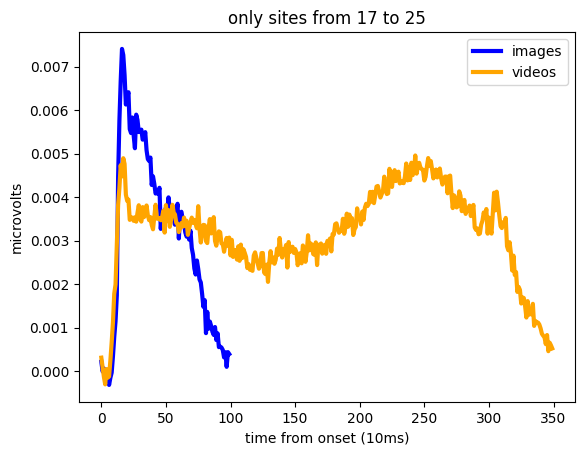

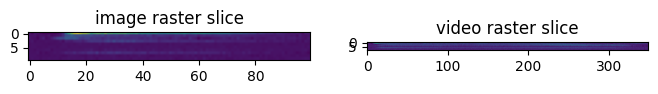

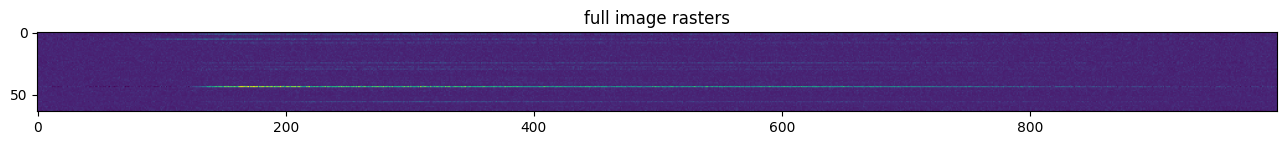

In [8]:
plt.plot(np.mean(image_ts.array[:, :, :], axis=(0,2)).T, color="blue", label="images", linewidth=cfg.linewidth)
plt.plot(np.mean(video_ts.array[:, :, :], axis=(0,2)).T, color="orange", label="videos", linewidth=cfg.linewidth)
plt.title("only sites from 17 to 25")
plt.ylabel("microvolts")
plt.xlabel("time from onset (10ms)")
plt.legend()
fig, ax = plt.subplots(1,2, figsize=(8,10))
ax[0].imshow(np.mean(image_ts.array, axis=2))
ax[0].set_title("image raster slice")
ax[1].set_title("video raster slice")
ax[1].imshow(np.mean(video_ts.array, axis=2))
fig = plt.figure(figsize=(16,18))
plt.imshow(np.mean(image_rasters, axis=2))
plt.title("full image rasters")


# DNN-dynamics style RSA

In [9]:
# Load all extracted model layers in numeric order (layer 0, 1, ..., 23).
model_features_dir = cfg.model_features_dir or Path(paths['data_path']) / 'models'
feature_paths = list_video_feature_files(
    model_features_dir, cfg.model_name, cfg.model_dataset_name, cfg.model_pooling,
)

# Reuse the shared subset so image and video model RDMs contain identical stimuli.
image_names_all = [Path(name).name for name in image_names]
video_names_all = [Path(name).name for name in video_names]
# Static image analyses use the final frame from the matching video feature set.
image_model_names = video_names_all

image_neural_ts = TimeSeries(
    image_rasters[:, :cfg.image_crop_ms, :], fs=1000,
)
video_neural_ts = TimeSeries(
    video_rasters, fs=1000,
)
if cfg.new_fs is not None:
    image_neural_ts.resample(cfg.new_fs)
    video_neural_ts.resample(cfg.new_fs)
# end if cfg.new_fs is not None

if cfg.normalization == 'min_max':
    # Re-estimate shared bounds using every condition included in the model analyses.
    normalization_reference = np.concatenate([
        image_neural_ts.get_array().reshape(image_neural_ts.shape()[0], -1),
        video_neural_ts.get_array().reshape(video_neural_ts.shape()[0], -1),
    ], axis=1)
    image_neural_ts.set_array(min_max_normalization(
        image_neural_ts.get_array(), reference_data=normalization_reference,
    ))
    video_neural_ts.set_array(min_max_normalization(
        video_neural_ts.get_array(), reference_data=normalization_reference,
    ))
# end if cfg.normalization == 'min_max'

print(f'{len(feature_paths)} model layers')
print(f'{len(image_names_all)} image stimuli aligned to final-frame model features')
print(f'{len(video_names_all)} video stimuli aligned to sequential model features')

32 model layers
100 image stimuli aligned to final-frame model features
100 video stimuli aligned to sequential model features


In [10]:
# Compute the neural image RDM once because it is shared by every model layer.
image_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)

image_drsa.compute_RDM_timeseries(image_ts, 'signal')

image_layer_drsa = []
layer_names = []
for feature_path in feature_paths:
    # The final frame has the same visual content as the corresponding static image.
    final_frame_features, layer_name, _ = load_aligned_video_features(
        feature_path, image_model_names, frame_index=-1,
    )
    model_RDM = create_RDM(final_frame_features, metric=cfg.model_RDM_metric)
    image_drsa.set_RDM(model_RDM, 'model')
    image_layer_drsa.append(image_drsa.compute_static_dRSA().get_array().copy())
    layer_names.append(layer_name)
# end for feature_path

image_layer_drsa = np.stack(image_layer_drsa, axis=0)
print(f'Image static dRSA: {image_layer_drsa.shape} (layers, neural time)')

Image static dRSA: (32, 100) (layers, neural time)


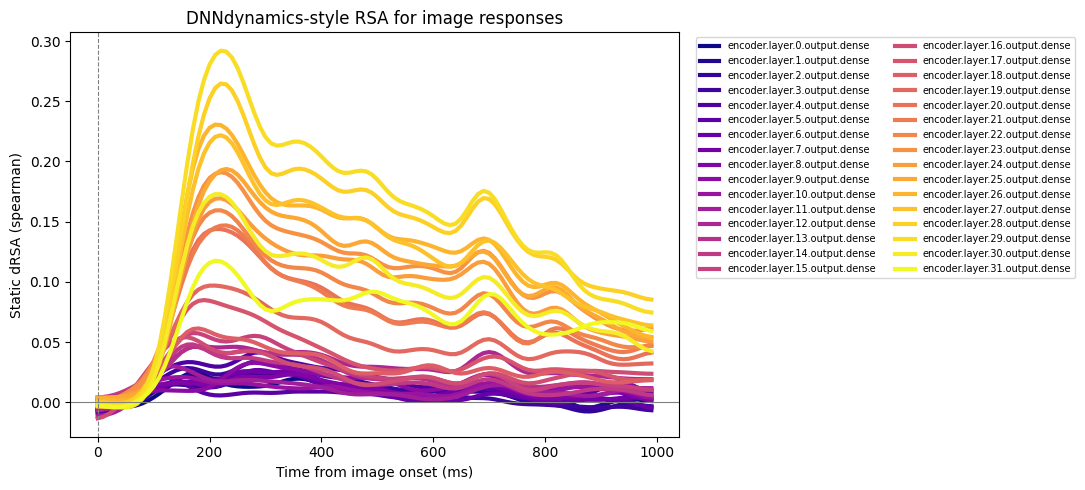

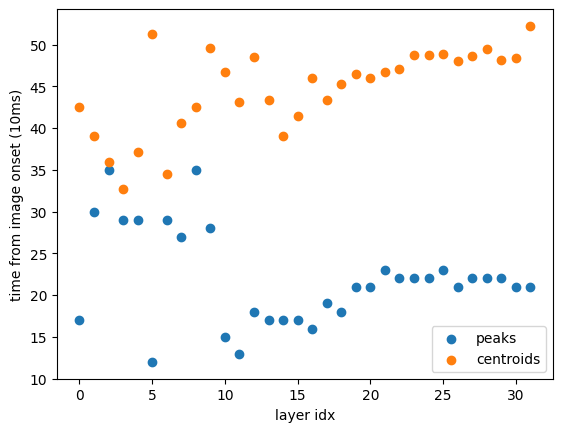

In [11]:
image_time_ms = np.arange(image_layer_drsa.shape[1]) * 1000 / image_neural_ts.get_fs()
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(layer_names)))
tot_centroids = []
tot_peaks = []
fig, ax = plt.subplots(figsize=(11, 5))
for layer_index, (layer_name, layer_drsa) in enumerate(
        zip(layer_names, image_layer_drsa),
        ):
    if cfg.smoothing:
        layer_drsa = gaussian_filter1d(layer_drsa, sigma=cfg.smoothing)
    nonzero_lp = copy.deepcopy(layer_drsa)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp/np.sum(nonzero_lp)
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    ax.plot(
        image_time_ms, layer_drsa, color=layer_colors[layer_index],
        linewidth=cfg.linewidth, label=layer_name,
    )
# end for layer_index
ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set(xlabel='Time from image onset (ms)',
       ylabel=f'Static dRSA ({cfg.RSA_metric})',
       title=f'DNNdynamics-style RSA for image responses')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7, ncol=2)
fig.tight_layout()
plt.figure()
plt.scatter(np.arange(len(tot_peaks)), tot_peaks, label="peaks")
plt.scatter(np.arange(len(tot_centroids)), tot_centroids, label="centroids")
plt.ylabel("time from image onset (10ms)")
plt.xlabel("layer idx")
plt.legend()



# Video dRSA
neural video timecourse modelled by frame-wise features


In [12]:
# Compute the neural video RDM once, then replace only the model RDM timecourse.
video_drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.model_RDM_metric,
    RSA_metric=cfg.video_RSA_metric,
)
video_drsa.compute_RDM_timeseries(video_ts, 'signal')

video_layer_drsa = {}
source_model_fs = None
for feature_path in feature_paths:
    model_features, layer_name, layer_model_fs = load_aligned_video_features(
        feature_path, video_names_all, frame_index=None,
    )

    # Match the model and neural time grids before computing the model RDM timecourse.
    model_ts = TimeSeries(model_features, fs=layer_model_fs)
    model_ts.resample(video_ts.get_fs())
    video_drsa.compute_RDM_timeseries(model_ts, 'model')
    video_layer_drsa[layer_name] = video_drsa.compute_dRSA().copy()

    if source_model_fs is None:
        source_model_fs = layer_model_fs
    elif source_model_fs != layer_model_fs:
        raise ValueError('Model layers have inconsistent source frame rates.')
    # end if source_model_fs is None
# end for feature_path

model_fs = video_neural_ts.get_fs()

example_video_drsa = video_layer_drsa[layer_names[cfg.example_layer]]
neural_time_ms = np.arange(example_video_drsa.shape[0]) * 1000 / video_neural_ts.get_fs()
model_time_ms = np.arange(example_video_drsa.shape[1]) * 1000 / model_fs
print(
    f'{cfg.example_layer} video dRSA: {example_video_drsa.shape} (neural time, model time); '
    f'model features resampled from {source_model_fs:g} to {model_fs:g} Hz'
)

30 video dRSA: (350, 300) (neural time, model time); model features resampled from 60 to 100 Hz


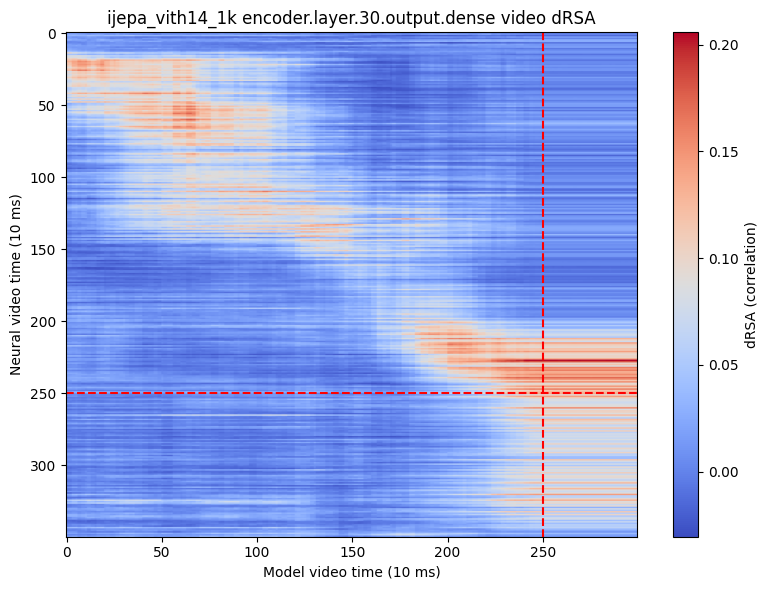

In [13]:
last_frame_ms = 2500
last_frame_idx = int(last_frame_ms*cfg.new_fs/1000)
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(
    example_video_drsa, aspect='auto', origin='upper', cmap='coolwarm',
)
ax.axvline(last_frame_idx, linestyle="--", color="red")
ax.axhline(last_frame_idx, linestyle="--", color="red")
ax.set(xlabel='Model video time (10 ms)', ylabel='Neural video time (10 ms)',
       title=f'{cfg.model_name} {layer_names[cfg.example_layer]} video dRSA')
fig.colorbar(image, ax=ax, label=f'dRSA ({cfg.video_RSA_metric})')
fig.tight_layout()

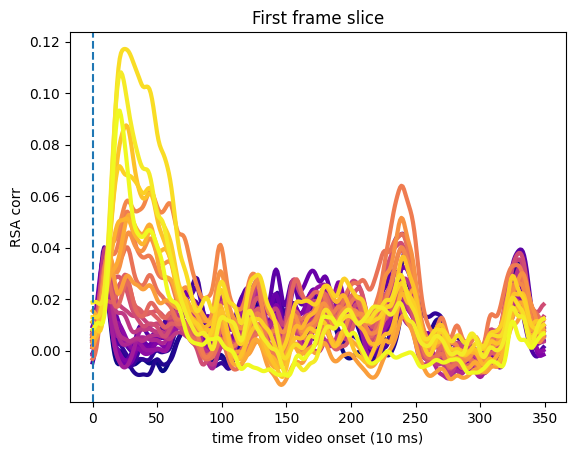

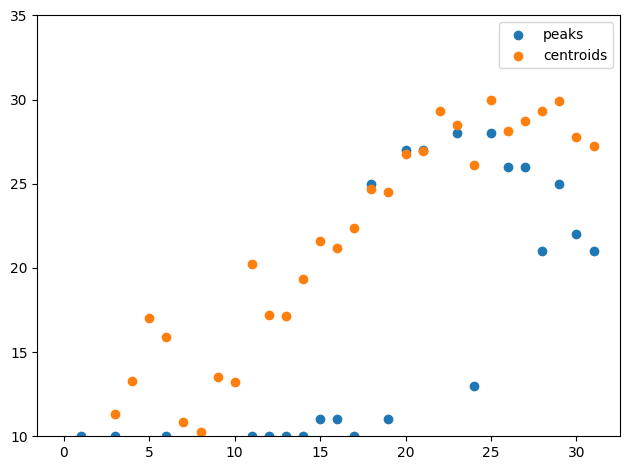

In [14]:
first_frame_ms = 0
beginning_ms, end_ms = 0, 500
beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
first_frame_idx = int(first_frame_ms*cfg.new_fs/1000)
tot_centroids = []
tot_peaks = []
window = 7  # smoothing window (samples)
kernel = np.ones(window) / window
# fig, ax = plt.subplots(1,2,figsize=(10,6))
for idx, l in enumerate(layer_names):
    drsa_mat = video_layer_drsa[l]
    if cfg.smoothing:
        lp = gaussian_filter1d(drsa_mat[:,first_frame_idx], sigma=cfg.smoothing)#kernel, mode="same")
    # lp[lp<0] = 0
    nonzero_lp = copy.deepcopy(lp)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp[beginning_idx:end_idx]/np.sum(nonzero_lp[beginning_idx:end_idx])
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    plt.plot(lp, color=layer_colors[idx], linewidth=cfg.linewidth)
plt.axvline(first_frame_idx, linestyle="--")
# ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
plt.ylabel("RSA corr")
plt.xlabel("time from video onset (10 ms)")
plt.title("First frame slice")
plt.figure()
plt.scatter(np.arange(len(tot_centroids)), tot_peaks, label="peaks")
plt.scatter(np.arange(len(tot_centroids)), tot_centroids, label="centroids")
plt.ylim([10, 35])
plt.legend()
plt.tight_layout()

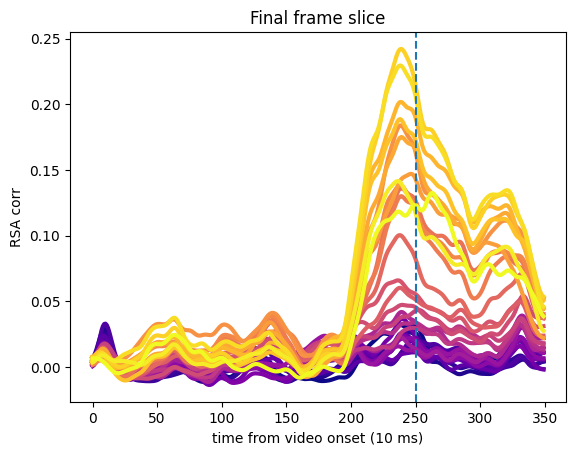

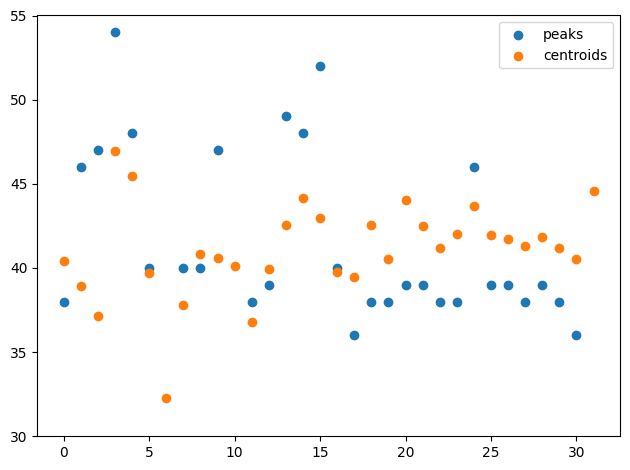

In [15]:
beginning_ms, end_ms = 2000, 2800
beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)

tot_centroids = []
tot_peaks = []
window = 7  # smoothing window (samples)
kernel = np.ones(window) / window
# fig, ax = plt.subplots(1,2,figsize=(10,6))
for idx, l in enumerate(layer_names):
    drsa_mat = video_layer_drsa[l]
    lp = gaussian_filter1d(drsa_mat[:,last_frame_idx], sigma=4)#kernel, mode="same")
    # lp[lp<0] = 0
    nonzero_lp = copy.deepcopy(lp)
    nonzero_lp[nonzero_lp<0] = 0
    normalized_lp = nonzero_lp[beginning_idx:end_idx]/np.sum(nonzero_lp[beginning_idx:end_idx])
    centroid = np.dot(normalized_lp, np.arange(len(normalized_lp)))
    tot_centroids.append(centroid)
    tot_peaks.append(np.argmax(normalized_lp))
    plt.plot(lp, color=layer_colors[idx], linewidth=cfg.linewidth)
plt.axvline(last_frame_idx, linestyle="--")
# ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
plt.ylabel("RSA corr")
plt.xlabel("time from video onset (10 ms)")
plt.title("Final frame slice")
plt.figure()
plt.scatter(np.arange(len(tot_centroids)), tot_peaks, label="peaks")
plt.scatter(np.arange(len(tot_centroids)), tot_centroids, label="centroids")
plt.ylim([30,55])
plt.legend()
plt.tight_layout()

In [16]:
# max_lag = 50
# beginning_ms, end_ms = 2000, 3000
# beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs
# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(10,100), model_idx=range(10,100), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("time from video onset (ms)")
# plt.title("From 0 to 1000ms")


In [17]:
# max_lag = 50
# beginning_ms, end_ms = 2000, 3000
# beginning_idx, end_idx = int(beginning_ms*cfg.new_fs/1000), int(end_ms*cfg.new_fs/1000)
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(80,250), model_idx=range(80,250), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("lag (ms)")
# plt.title("From 1000 to 2000ms")


In [18]:
# max_lag = 30
# lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

# tot_centroids = []
# tot_peaks = []
# window = 7  # smoothing window (samples)
# kernel = np.ones(window) / window
# # fig, ax = plt.subplots(1,2,figsize=(10,6))
# for idx, l in enumerate(layer_names):
#     drsa_mat = video_layer_drsa[l]
#     lp = get_lagplot_subset(drsa_mat, neural_idx=range(200,250), model_idx=range(200,250), max_lag=max_lag)
#     plt.plot(lags, lp, color=layer_colors[idx], linewidth=cfg.linewidth)
# # ax[0].set_xticks(np.arange(len(lp))[0:-1:30]);
# # ax[0].set_xticklabels(np.round(np.arange(len(lp))*1000/60).astype(int)[0:-1:30]);
# plt.axvline(0, linestyle="--", color="red")
# plt.ylabel("RSA corr")
# plt.xlabel("lag (ms)")
# plt.title("From 1000 to 2000ms")


# Raw lagged correlation between image and video neural activity

In [19]:
running_sum = None
for i in range(video_ts.shape()[2]):
    v = TimeSeries(video_ts.array[:,:,i], cfg.new_fs)
    i = TimeSeries(image_ts.array[:,:,i], cfg.new_fs)
    if running_sum is None:
        running_sum = v.lagged_corr(i)
    else:
        running_sum += v.lagged_corr(i)

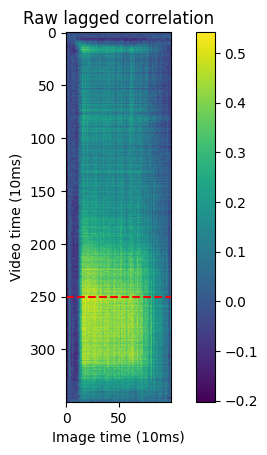

In [20]:
plt.imshow(running_sum/video_ts.shape()[2])
plt.axhline(last_frame_idx, linestyle="--", color="red")
plt.title("Raw lagged correlation")
plt.xlabel("Image time (10ms)")
plt.ylabel("Video time (10ms)")
plt.colorbar()

# Image-movie Dynamic RSA

In [21]:
drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.signal_RDM_metric,
    RSA_metric="correlation",
)
drsa.compute_both_RDM_timeseries(video_ts, image_ts)
corr_mat = drsa.compute_dRSA()
autocorr_vid, _ = drsa.get_RDM_timeseries("signal").autocorr()
autocorr_img, _ = drsa.get_RDM_timeseries("model").autocorr()


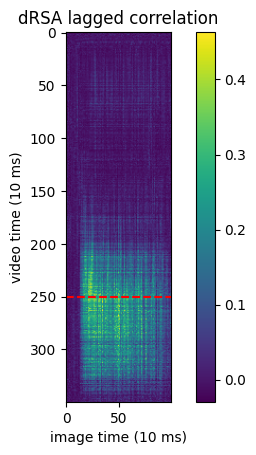

In [22]:
plt.imshow(corr_mat)
plt.ylabel("video time (10 ms)")
plt.xlabel("image time (10 ms)")
plt.axhline(last_frame_idx, linestyle="--", color="red")
plt.title("dRSA lagged correlation")
plt.colorbar()


In [23]:
mat, lp = drsa.signal_RDM_timeseries.autocorr()

In [24]:
mat[200:300, 200:300].shape

(100, 100)

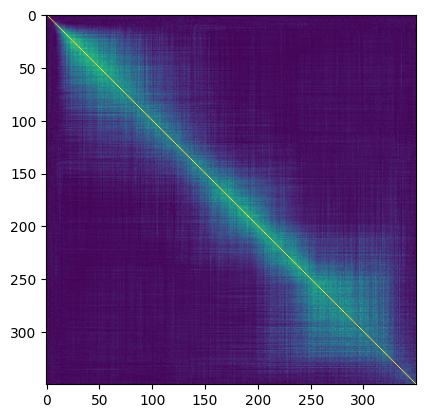

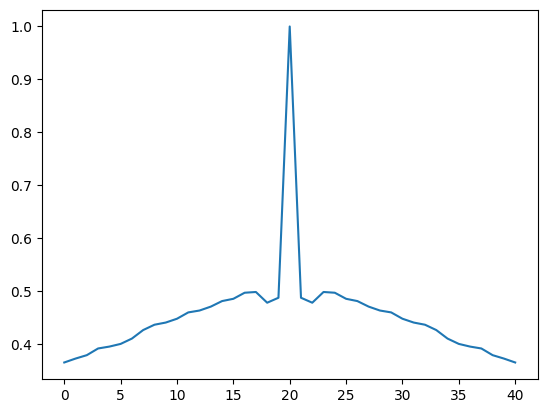

In [25]:
plt.imshow(mat)
plt.figure()
plt.plot(get_lagplot(mat[200:300, 200:300], max_lag=20))

array([[-0.0078903 ,  0.01291286,  0.00145924, ...,  0.00302517,
         0.01908408,  0.05621592],
       [-0.01655007,  0.00792931, -0.0032801 , ...,  0.0263066 ,
        -0.01013461,  0.02514875],
       [-0.007211  ,  0.00238314,  0.00198769, ...,  0.0124925 ,
        -0.00252894,  0.01513275],
       ...,
       [-0.00423444,  0.00913489, -0.00840602, ...,  0.04526035,
         0.08119445,  0.03469761],
       [-0.00907923, -0.00648073, -0.00655183, ...,  0.03064807,
         0.05592013,  0.06294932],
       [ 0.02064713, -0.00594443, -0.00310331, ...,  0.01619759,
         0.05079972,  0.06994481]], shape=(100, 100))

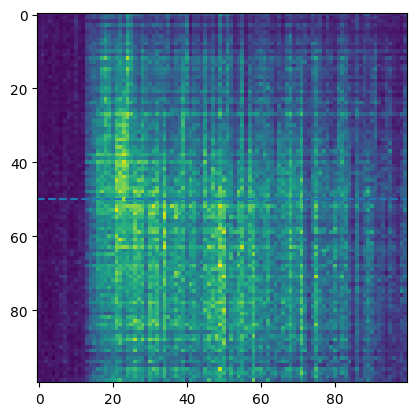

In [26]:
plt.imshow(corr_mat[200:300, :])
plt.axhline(50, linestyle="--")
corr_mat[200:300, :]

Text(0.5, 1.0, 'Static to dynamic lagplot')

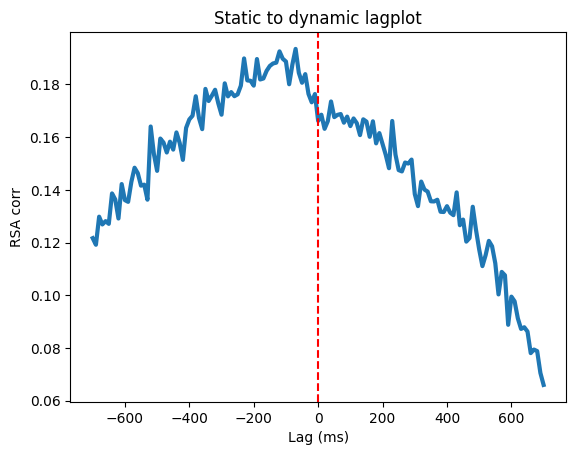

In [27]:
max_lag = 70
lagplot = get_lagplot(corr_mat[250:340, 10:100], max_lag=max_lag)
lags = np.arange(-max_lag, max_lag + 1)*1000/cfg.new_fs

plt.plot(lags, lagplot, linewidth=cfg.linewidth)
plt.axvline(0, color="red", linestyle="--")

plt.xlabel("Lag (ms)")
plt.ylabel("RSA corr")
plt.title("Static to dynamic lagplot")


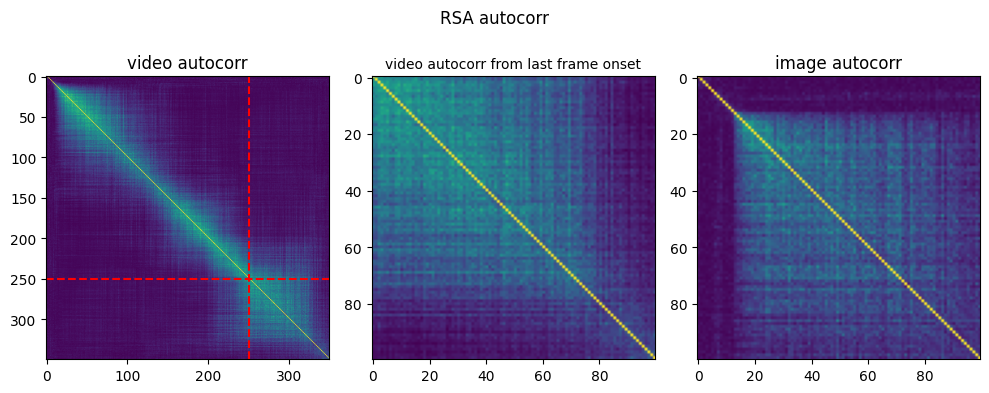

In [28]:
fig, ax = plt.subplots(1,3, figsize=(10,4))

ax[0].imshow(autocorr_vid)
ax[0].set_title("video autocorr")
ax[0].axhline(last_frame_idx, linestyle="--", color="red")
ax[0].axvline(last_frame_idx, linestyle="--", color="red")
ax[1].imshow(autocorr_vid[last_frame_idx:, last_frame_idx:])
ax[1].set_title("video autocorr from last frame onset", fontsize=10)
ax[2].imshow(autocorr_img)
ax[2].set_title("image autocorr")
fig.suptitle("RSA autocorr")
fig.tight_layout()

In [29]:
drsa = dRSA(
    signal_RDM_metric=cfg.signal_RDM_metric,
    model_RDM_metric=cfg.signal_RDM_metric,
    RSA_metric="correlation",
)
delay_emb_video_ts = video_ts.delay_embeddings(lags=(-5, 5), pad_mode="edge")
delay_emb_image_ts = image_ts.delay_embeddings(lags=(-5, 5), pad_mode="edge")
drsa.compute_both_RDM_timeseries(delay_emb_video_ts, delay_emb_image_ts)
corr_mat = drsa.compute_dRSA()
autocorr_vid, _ = drsa.get_RDM_timeseries("signal").autocorr()
autocorr_img, _ = drsa.get_RDM_timeseries("model").autocorr()


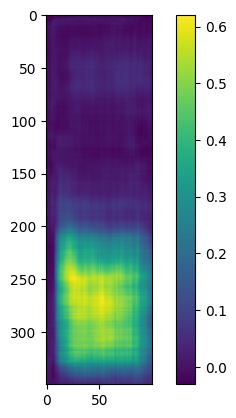

In [30]:
plt.imshow(corr_mat)
plt.colorbar()